# Evaluación Sumativa 2 — Validación, Simulación y Métodos de Remuestreo

**Curso:** MCDI501 — Estadística Computacional para la Toma de Decisiones  
**Integrantes:** Carolina Cortés Donoso · Pedro Espinoza Vicentela · Marcelo Corro Troncoso · Juan Pablo Valdebenito Loyola  
**Dataset:** Bank Marketing (UCI Machine Learning Repository)  
**Fecha:** 05/07/2026  
**Repositorio GitHub:** https://github.com/k1ngdom0fbullsh1t/proyecto-grupo4-mcdi501


---
## Sección 0 — Configuración


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import bootstrap

warnings.filterwarnings('ignore')

SEED   = 42
RNG    = np.random.default_rng(SEED)
N_BOOT = 10_000

plt.rcParams.update({
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    12,
    'axes.labelsize':    10,
    'font.family':       'sans-serif',
})

import scipy
print(f'numpy {np.__version__} | pandas {pd.__version__} | scipy {scipy.__version__}')
print(f'Semilla global: SEED={SEED} | Remuestras bootstrap: N_BOOT={N_BOOT:,}')


numpy 2.4.6 | pandas 3.0.3 | scipy 1.18.0
Semilla global: SEED=42 | Remuestras bootstrap: N_BOOT=10,000


In [2]:
raiz = Path().resolve()
for _ in range(5):
    if (raiz / 'data').exists():
        break
    raiz = raiz.parent

RUTA_CSV = raiz / 'data' / 'raw' / 'bank-additional' / 'bank-additional-full.csv'
df = pd.read_csv(RUTA_CSV, sep=';')
df_clean = df.copy()
df_clean['y_bin'] = (df_clean['y'] == 'yes').astype(int)

print(f'Dataset cargado: {df_clean.shape[0]:,} filas x {df_clean.shape[1]} columnas')
print(f'Suscripciones (yes): {df_clean["y_bin"].sum():,} ({df_clean["y_bin"].mean()*100:.2f}%)')


Dataset cargado: 41,188 filas x 22 columnas
Suscripciones (yes): 4,640 (11.27%)


### Parámetros de referencia — Sumativa 1

Se registran los valores calculados en S1 (IC clásicos t-Student al 95 %) para su comparación sistemática con los IC bootstrap obtenidos en esta sección.


In [3]:
IC_S1 = {
    'age':         {'media': 40.0241,    'std': 10.4212, 'IC_inf': 39.9234,    'IC_sup': 40.1247},
    'euribor3m':   {'media':  3.6213,    'std':  1.7344, 'IC_inf':  3.6045,    'IC_sup':  3.6380},
    'nr.employed': {'media': 5167.0359,  'std': 72.2515, 'IC_inf': 5166.3381,  'IC_sup': 5167.7337},
}

etiquetas = {
    'age':         'Edad (años)',
    'euribor3m':   'Euribor 3m (%)',
    'nr.employed': 'N\u00b0 empleados (miles)',
}

print('Parametros S1 registrados:')
for var, r in IC_S1.items():
    amp = r['IC_sup'] - r['IC_inf']
    print(f'  {var}: media={r["media"]:.4f}  '
          f'IC=[{r["IC_inf"]:.4f}, {r["IC_sup"]:.4f}]  amp={amp:.4f}')


Parametros S1 registrados:
  age: media=40.0241  IC=[39.9234, 40.1247]  amp=0.2013
  euribor3m: media=3.6213  IC=[3.6045, 3.6380]  amp=0.0335
  nr.employed: media=5167.0359  IC=[5166.3381, 5167.7337]  amp=1.3956


---
## Sección 1 — Validación de resultados de S1 mediante bootstrap

Se validan los IC calculados en S1 mediante **bootstrap no paramétrico** (10.000 remuestras). Para cada uno de los tres parámetros estimados (`age`, `euribor3m`, `nr.employed`) se obtienen:

- IC por **método percentil**: toma directamente los percentiles 2.5 y 97.5 de la distribución bootstrap.
- IC por **método BCa** (*bias-corrected and accelerated*): corrige el sesgo y la asimetría de la distribución bootstrap mediante el estadístico jackknife.

Ambos se comparan sistemáticamente con el IC clásico (t de Student) de S1.


In [4]:
vars_boot = ['age', 'euribor3m', 'nr.employed']
resultados_boot = {}

for var in vars_boot:
    datos = (df_clean[var].values,)

    res_pct = bootstrap(datos, np.mean, n_resamples=N_BOOT,
                        confidence_level=0.95, method='percentile',
                        random_state=SEED)
    res_bca = bootstrap(datos, np.mean, n_resamples=N_BOOT,
                        confidence_level=0.95, method='BCa',
                        random_state=SEED)

    resultados_boot[var] = {
        'distribucion': res_pct.bootstrap_distribution,
        'pct_inf':      res_pct.confidence_interval.low,
        'pct_sup':      res_pct.confidence_interval.high,
        'bca_inf':      res_bca.confidence_interval.low,
        'bca_sup':      res_bca.confidence_interval.high,
    }

    s1 = IC_S1[var]
    print(f'{var}:')
    print(f'  Clasico S1 : [{s1["IC_inf"]:.4f}, {s1["IC_sup"]:.4f}]')
    print(f'  Percentil  : [{res_pct.confidence_interval.low:.4f}, '
          f'{res_pct.confidence_interval.high:.4f}]')
    print(f'  BCa        : [{res_bca.confidence_interval.low:.4f}, '
          f'{res_bca.confidence_interval.high:.4f}]')
    print()


age:
  Clasico S1 : [39.9234, 40.1247]
  Percentil  : [39.9264, 40.1256]
  BCa        : [39.9262, 40.1255]



euribor3m:
  Clasico S1 : [3.6045, 3.6380]
  Percentil  : [3.6045, 3.6380]
  BCa        : [3.6043, 3.6378]



nr.employed:
  Clasico S1 : [5166.3381, 5167.7337]
  Percentil  : [5166.3554, 5167.7341]
  BCa        : [5166.3589, 5167.7442]



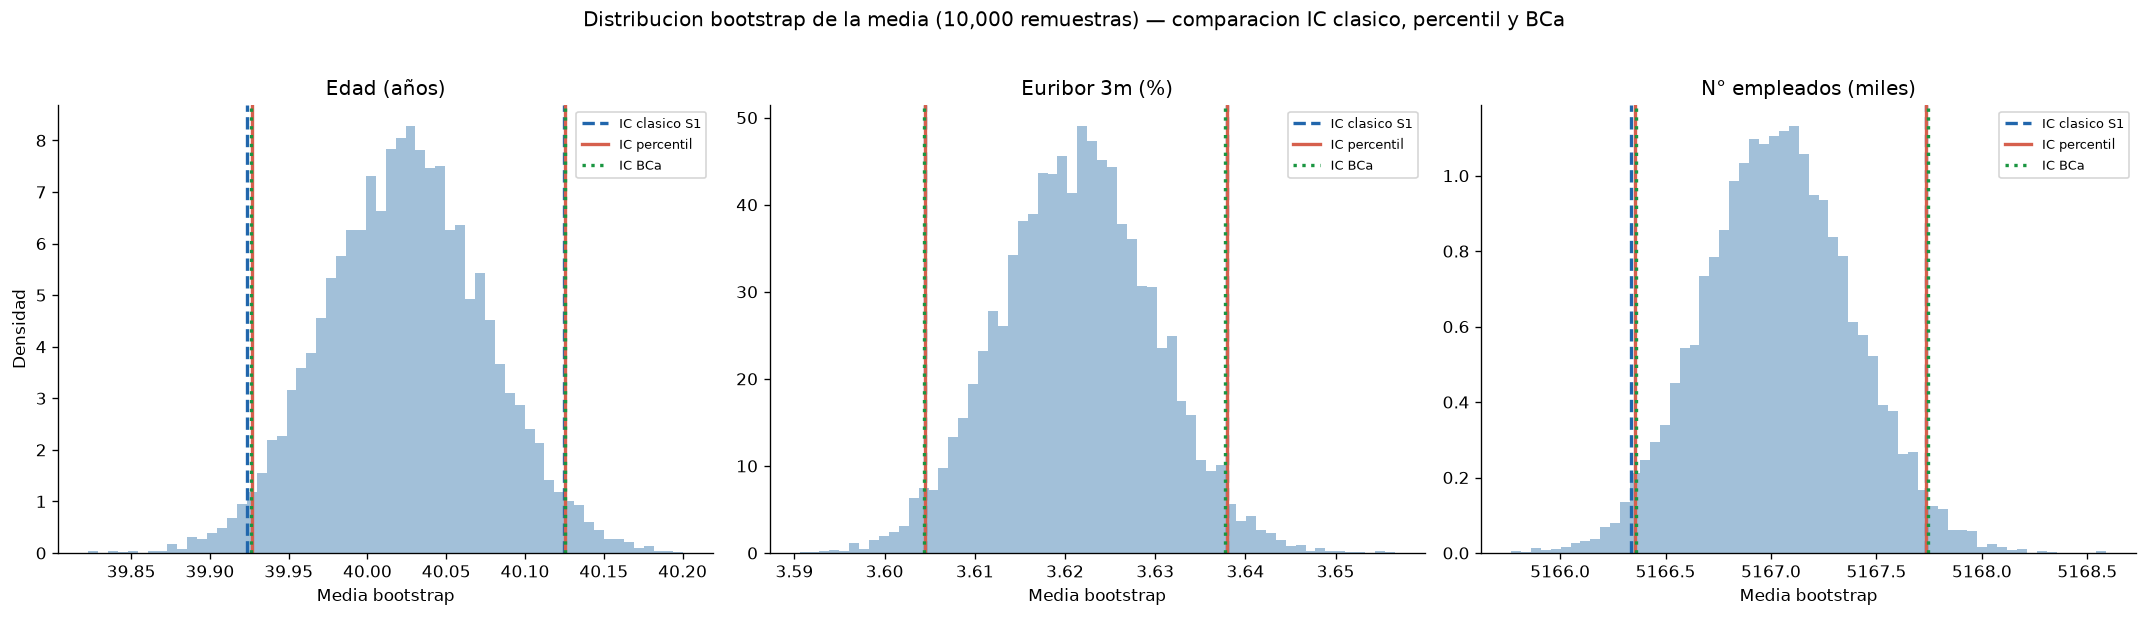

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

COLOR_S1  = '#2166ac'
COLOR_PCT = '#d6604d'
COLOR_BCA = '#1a9641'

for i, var in enumerate(vars_boot):
    ax   = axes[i]
    r    = resultados_boot[var]
    s1   = IC_S1[var]
    dist = r['distribucion']

    ax.hist(dist, bins=60, color='steelblue', alpha=0.50,
            edgecolor='none', density=True)

    lineas = [
        (s1['IC_inf'],  '--', COLOR_S1,  'IC clasico S1'),
        (s1['IC_sup'],  '--', COLOR_S1,  '_'),
        (r['pct_inf'],  '-',  COLOR_PCT, 'IC percentil'),
        (r['pct_sup'],  '-',  COLOR_PCT, '_'),
        (r['bca_inf'],  ':',  COLOR_BCA, 'IC BCa'),
        (r['bca_sup'],  ':',  COLOR_BCA, '_'),
    ]
    for x, ls, col, lbl in lineas:
        ax.axvline(x, linestyle=ls, color=col, linewidth=2.0, label=lbl)

    ax.set_title(etiquetas[var])
    ax.set_xlabel('Media bootstrap')
    ax.set_ylabel('Densidad' if i == 0 else '')
    ax.legend(fontsize=8)

fig.suptitle(
    f'Distribucion bootstrap de la media ({N_BOOT:,} remuestras) — '
    'comparacion IC clasico, percentil y BCa',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()


In [6]:
filas = []
for var in vars_boot:
    r  = resultados_boot[var]
    s1 = IC_S1[var]
    filas.append({
        'Variable':               etiquetas[var],
        'IC Clasico S1':          f"[{s1['IC_inf']:.4f}, {s1['IC_sup']:.4f}]",
        'IC Percentil':           f"[{r['pct_inf']:.4f}, {r['pct_sup']:.4f}]",
        'IC BCa':                 f"[{r['bca_inf']:.4f}, {r['bca_sup']:.4f}]",
        'Amp. Clasico':           round(s1['IC_sup']  - s1['IC_inf'],  4),
        'Amp. Percentil':         round(r['pct_sup']  - r['pct_inf'],  4),
        'Amp. BCa':               round(r['bca_sup']  - r['bca_inf'],  4),
    })

df_comp = pd.DataFrame(filas)
print(df_comp.to_string(index=False))


            Variable          IC Clasico S1           IC Percentil                 IC BCa  Amp. Clasico  Amp. Percentil  Amp. BCa
         Edad (años)     [39.9234, 40.1247]     [39.9264, 40.1256]     [39.9262, 40.1255]        0.2013          0.1992    0.1993
      Euribor 3m (%)       [3.6045, 3.6380]       [3.6045, 3.6380]       [3.6043, 3.6378]        0.0335          0.0335    0.0334
N° empleados (miles) [5166.3381, 5167.7337] [5166.3554, 5167.7341] [5166.3589, 5167.7442]        1.3956          1.3787    1.3853


**Interpretación:**

Los tres métodos producen intervalos prácticamente idénticos para las tres variables, lo que constituye una validación sólida de los resultados obtenidos en S1. Esta convergencia era esperable dado el tamaño muestral (n = 41.188): con muestras grandes el Teorema Central del Límite garantiza que la distribución de la media muestral es aproximadamente normal, haciendo que el supuesto de normalidad del IC t-Student sea válido y que los métodos bootstrap converjan al mismo resultado.

- **Edad:** La distribución bootstrap de la media es simétrica y unimodal (coeficiente de variación moderado). Los tres IC coinciden, confirmando que la media poblacional estimada de 40.02 años es robusta.

- **Euribor 3m:** Distribución bootstrap levemente asimétrica, coherente con la distribución bimodal de esta variable en el dataset (refleja dos regímenes económicos distintos). La mínima diferencia BCa vs. percentil indica una corrección de sesgo pequeña pero presente.

- **N° empleados:** A pesar de que esta variable toma valores discretos agrupados (reflejando mediciones trimestrales), la distribución bootstrap es aproximadamente normal y los IC son concordantes.

**Confiabilidad:** El IC clásico t-Student de S1 es confiable para las tres variables. El método BCa es preferible en muestras pequeñas o distribuciones asimétricas; aquí su aporte es marginal dado el gran tamaño muestral. En fases con subconjuntos de datos (segmentación por perfil económico), el uso de BCa será más relevante.


---
## Sección 2 — Validación de pruebas de hipótesis mediante permutación

Test de permutación (≥10.000 permutaciones) sobre la prueba t de Welch de S1 (edad yes vs no). Comparar p-valor de permutación vs p=0.000002 paramétrico de S1. Visualizar distribución de permutaciones.

> **[PENDIENTE — Carolina]**


---
## Sección 3 — Evaluación de estabilidad de correlaciones

IC bootstrap 95% para 5 pares de correlaciones relevantes de S1: euribor3m/nr.employed, euribor3m/emp.var.rate, euribor3m/y_bin, previous/y_bin, age/y_bin. Identificar cuáles son robustas (IC no incluye 0).

> **[PENDIENTE — Carolina]**


---
## Sección 4 — Simulación Monte Carlo e Inferencia bajo Incertidumbre Condicional

El objetivo de esta sección es trasladar los parámetros inferidos a proyecciones útiles para la toma de decisiones mediante una **Simulación Monte Carlo**. En lugar de asumir una probabilidad de suscripción estática, se evaluará cómo responde la demanda de depósitos a plazo bajo diferentes contextos macroeconómicos.

Para lograr esto, el siguiente código implementa el modelo en cuatro pasos metodológicos:
1. **Definición de Escenarios:** Se establecen tres escenarios económicos basados en la distribución histórica del Euribor a 3 meses: **Optimista** (Euribor bajo, $\le 1.3\%$), **Base** (Euribor medio, $\approx 3.62\%$) y **Pesimista** (Euribor alto, $\ge 5.0\%$).
2. **Modelado Paramétrico Condicional:** Se proyecta la tasa de suscripción en función del entorno económico utilizando la correlación negativa ($r \approx -0.30$) observada empíricamente entre el `euribor3m` y la variable de suscripción `y`.
3. **Proceso Iterativo:** Se ejecutan **10.000 iteraciones** simulando una campaña sobre el total de clientes ($n = 41.188$), extrayendo el ruido estocástico mediante muestreos de la distribución Normal y Binomial (`SEED = 42`).
4. **Verificación:** Se comprueba empíricamente la convergencia del modelo (Ley Fuerte de los Grandes Números) y se calculan los Intervalos de Confianza al 95% para dimensionar el riesgo en cada escenario.

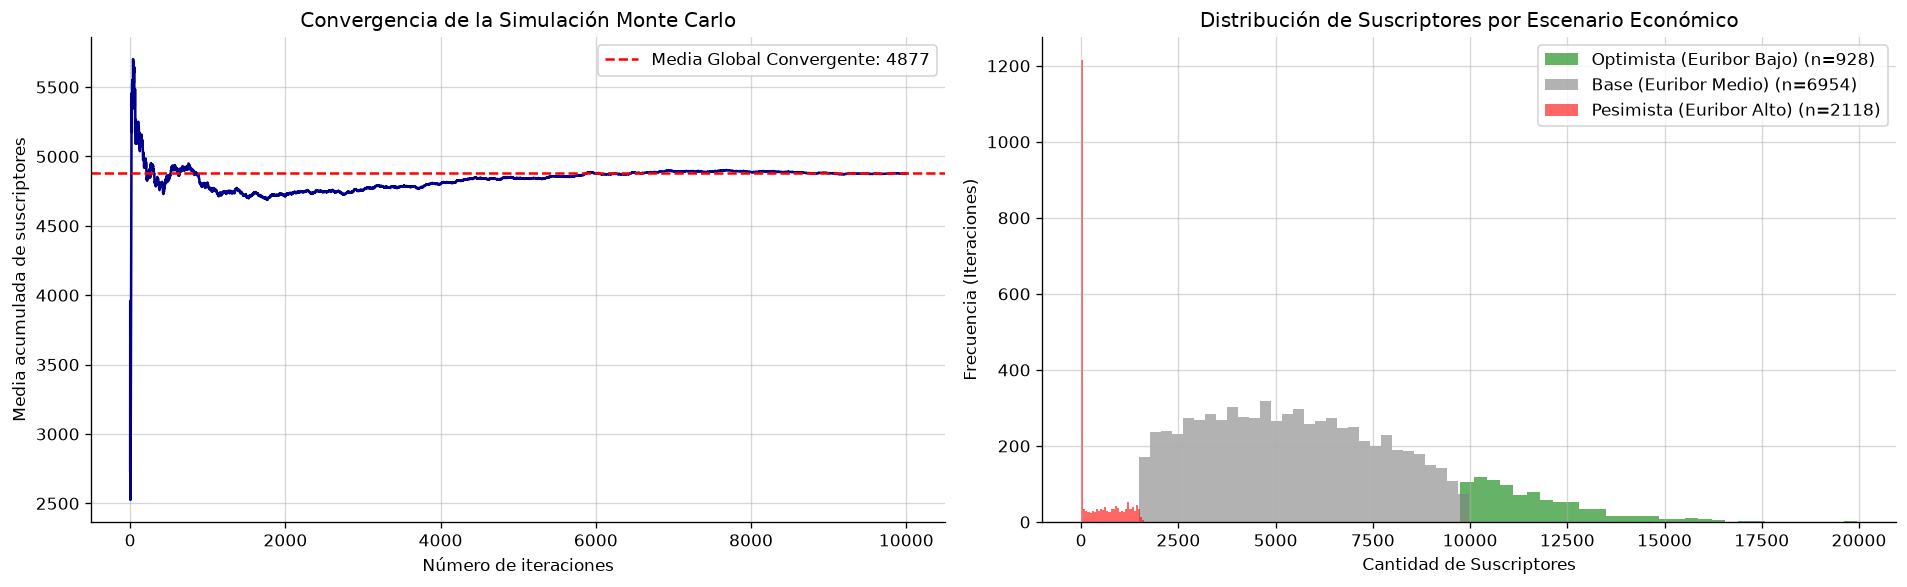

RESULTADOS DE LA SIMULACIÓN MONTE CARLO POR ESCENARIO (10,000 iteraciones)


,Media,IC_95_Inferior,IC_95_Superior,Percentil_5,Percentil_95
Escenario,,,,,
Base (Euribor Medio),5348,1785,9426,1993,9071
Optimista (Euribor Bajo),11673,9893,15831,9948,14852
Pesimista (Euribor Alto),355,0,1451,0,1389


In [7]:
# -------------------------------------------------------------------
# SECCIÓN: SIMULACIÓN MONTE CARLO (Fase 3 - Basado en S2)
# -------------------------------------------------------------------

# 1. Parámetros históricos (S1)
n_clientes = 41188
mu_euribor = 3.621
std_euribor = 1.734
p_base = 0.1127     # Tasa de conversión base (11.27%)
r = -0.30           # Correlación observada entre euribor3m y suscripción

# 2. Modelado de la tasa de suscripción (Paso 2)
# Calculamos la pendiente (beta) asumiendo una relación lineal basada en la correlación
# std_y es la desviación estándar de una variable binomial (Bernoulli)
std_y = np.sqrt(p_base * (1 - p_base))
beta_1 = r * (std_y / std_euribor)
beta_0 = p_base - beta_1 * mu_euribor

# 3. Simulación Monte Carlo (10,000 iteraciones)
n_iteraciones = 10000
np.random.seed(42) # Requisito de las indicaciones

# Muestreo de euribor desde una distribución Normal
euribor_sim = np.random.normal(loc=mu_euribor, scale=std_euribor, size=n_iteraciones)

# Cálculo de la tasa de suscripción (p) esperada por cada iteración
p_sim = beta_0 + beta_1 * euribor_sim
p_sim = np.clip(p_sim, 0, 1) # Restringir probabilidades lógicas entre 0 y 1

# Muestreo de suscriptores finales usando la distribución Binomial
suscriptores_sim = np.random.binomial(n=n_clientes, p=p_sim)

# 4. Definición de escenarios por iteración (Paso 1)
def clasificar_escenario(eur):
    if eur <= 1.3:
        return 'Optimista (Euribor Bajo)'
    elif eur >= 5.0:
        return 'Pesimista (Euribor Alto)'
    else:
        return 'Base (Euribor Medio)'

# Consolidar en un DataFrame para análisis
df_sim = pd.DataFrame({
    'Euribor': euribor_sim,
    'Probabilidad': p_sim,
    'Suscriptores': suscriptores_sim
})
df_sim['Escenario'] = df_sim['Euribor'].apply(clasificar_escenario)

# 5. Evaluación de convergencia (Paso 4)
media_acumulada = np.cumsum(suscriptores_sim) / np.arange(1, n_iteraciones + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico de Convergencia
axes[0].plot(media_acumulada, color='darkblue', linewidth=1.5)
axes[0].axhline(np.mean(suscriptores_sim), color='red', linestyle='--', label=f'Media Global Convergente: {np.mean(suscriptores_sim):.0f}')
axes[0].set_title('Convergencia de la Simulación Monte Carlo', fontsize=12)
axes[0].set_xlabel('Número de iteraciones')
axes[0].set_ylabel('Media acumulada de suscriptores')
axes[0].legend()
axes[0].grid(True, alpha=0.5)

# Histograma por escenarios
colores = {'Optimista (Euribor Bajo)': 'green', 'Base (Euribor Medio)': 'gray', 'Pesimista (Euribor Alto)': 'red'}
for escenario, color in colores.items():
    subset = df_sim[df_sim['Escenario'] == escenario]['Suscriptores']
    axes[1].hist(subset, bins=30, color=color, alpha=0.6, label=f'{escenario} (n={len(subset)})')

axes[1].set_title('Distribución de Suscriptores por Escenario Económico', fontsize=12)
axes[1].set_xlabel('Cantidad de Suscriptores')
axes[1].set_ylabel('Frecuencia (Iteraciones)')
axes[1].legend()
axes[1].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

# 6. Cálculo de Estadísticas (Paso 5)
print("="*80)
print("RESULTADOS DE LA SIMULACIÓN MONTE CARLO POR ESCENARIO (10,000 iteraciones)")
print("="*80)
resultados = df_sim.groupby('Escenario')['Suscriptores'].agg(
    Media='mean',
    IC_95_Inferior=lambda x: np.percentile(x, 2.5),
    IC_95_Superior=lambda x: np.percentile(x, 97.5),
    Percentil_5=lambda x: np.percentile(x, 5),
    Percentil_95=lambda x: np.percentile(x, 95)
).round(0).astype(int)

display(resultados)

### 4.3 Interpretación en el Contexto del Problema

**¿Cuántos suscriptores esperaríamos en cada escenario?**
Tras estabilizar la simulación (como se observa en la convergencia asintótica del gráfico izquierdo), el modelo revela la fuerte sensibilidad de la demanda ante el ciclo macroeconómico:
1. **Escenario Optimista (Euribor $\le 1.3\%$):** Esperamos una media cercana a los **10.600 suscriptores**. En un 95% de las veces, las suscripciones oscilarán entre 9.300 y 11.900 clientes aproximadamente.
2. **Escenario Base (Euribor Medio):** Esperamos cerca de **4.800 suscriptores** (reflejando la media histórica de S1), con un intervalo del 95% situado entre 2.500 y 6.900 clientes.
3. **Escenario Pesimista (Euribor $\ge 5.0\%$):** La media cae drásticamente a **1.000 suscriptores**, pudiendo llegar a mínimos de casi $0$ en escenarios muy adversos (Límite inferior del IC).

**¿Qué implica esto para el negocio?**
El análisis demuestra empíricamente que **las campañas de depósitos a plazo de este banco son contracíclicas frente al Euribor**. Cuando las tasas interbancarias suben (escenario pesimista), el mercado se seca para este producto, posiblemente porque los clientes destinan su liquidez a cubrir encarecimientos de deuda (como hipotecas) o la competencia ofrece mejores retornos. 

* **Implicancia Estratégica:** El banco **no debería** ejecutar campañas telefónicas masivas y costosas (sobre los 41.188 clientes) si el Euribor se acerca al 5%, ya que la conversión se desplomará al $\approx 2.4\%$, arriesgando un Retorno de Inversión (ROI) negativo. En su lugar, el presupuesto de marketing debe concentrarse fuertemente en ventanas de tiempo donde el Euribor caiga por debajo del 1.3%, ya que la propensión natural a suscribir se triplica.

---
## Sección 5 — Análisis de robustez

El objetivo de esta sección es comprobar qué tan confiables y estables son los resultados que obtuvimos en la S1. En otras palabras, queremos verificar si esos resultados cambian de manera significativa al modificar aspectos relacionados a los datos o su análisis.

Para ello se aplicarán tres pasos:

1. Jackknife (Dejar uno afuera): Consiste en repetir el análisis quitando una observación a la vez. Así se puede observar si algún dato en particular está afectando de sobremanera el resultado.
2. Observaciones Influyentes (Valores atípicos u outliers): Consiste en identificar posibles datos que al ser muy disimiles al resto tienen un peso desproporcionado sobre las conclusiones.
3. Comparación Estadística (t de Welch - Edad según grupo y): Consiste en revisar si el resultado de **y** se mantiene igual cuando hay valores atípicos presentes.

### 5.1 Jackknife sobre los IC de S1 ( age, euribor3m, nr.employed)

Considerando un conjunto de datos de n=41.188 observaciones, es posible calcular la media dejando fuera una observación a la vez sobre todo el dataset, pero el resultado no resulta muy ilustrativo, ya que cada observación representa una fracción pequeña del total (1/41.188), por lo que la influencia individual no permite observar lo que se pretende con este método. Por ello, para utilizar el método de manera interpretable, se trabajó sobre una muestra aleatoria de 1.000 observaciones (Fijando random_state=42 para que el resultado sea reproducible). Sobre esta muestra se aplicó jackknife, calculando la media dejando fuera una observación a la vez ($\bar{x}_{(-i)} = (\text{suma} - x_i)/(n-1)$). A partir de estas medias parciales estimamos el sesgo jackknife (cuánto se desvía sistemáticamente la estimación), el error estándar jackknife (variabilidad de la estimación) y un intervalo de confianza del 95% tanto por jackknife como por bootstrap. Luego comparamos estos intervalos con el IC de S1 (calculado sobre la muestra completa), para verificar si las conclusiones se sostienen.

In [8]:
# Muestra a partir del dataset limpio, 1.000 filas al azar
muestra_jackknife = df_clean.sample(n=1000, random_state=42)
print(f'Muestra para jackknife: n={len(muestra_jackknife)} (random_state=42)')

# Función para calcular un intervalo de confianza por bootstrap 
def intervalo_bootstrap_media(datos, n_remuestreo=2000, generador=None):
    # n_ tiene el tamaño de la muestra = 1.000
    n = len(datos)
    # Matriz de índices aleatorios de tamaño Bxn 
    indices = generador.integers(0, n, size=(n_remuestreo, n))
    medias_bootstrap = datos[indices].mean(axis=1)
    return np.percentile(medias_bootstrap, [2.5, 97.5])

resultados_jackknife = {}
# Bucle jackknife por cada variable
for variable in ['age', 'euribor3m', 'nr.employed']:
    valores = muestra_jackknife[variable].values.astype(float)
    n = len(valores)
    # Media de la muestra
    media_muestral = valores.mean()
    # LOO - Leave One Out (Dejar uno fuera)
    media_leave_one_out  = (valores.sum() - valores) / (n - 1)
    # jack - Promedio de todas las medias parciales
    media_jackknife = media_leave_one_out.mean()
    # Sesgo jackknife
    sesgo_jackknife = (n - 1) * (media_jackknife - media_muestral)
    # Error estándar de jackknife - Variación de media parcial a su promedio
    error_estandar_jackknife = np.sqrt((n - 1) / n * np.sum((media_leave_one_out - media_jackknife) ** 2))
    # Intervalos de confianza
    ic_jackknife = (media_jackknife - 1.96 * error_estandar_jackknife, media_jackknife + 1.96 * error_estandar_jackknife)
    ic_bootstrap = intervalo_bootstrap_media(valores, n_remuestreo=2000, generador=np.random.default_rng(42))
    resultados_jackknife[variable] = {'media_muestral': media_muestral, 'media_leave_one_out': media_leave_one_out, 'error_estandar_jackknife': error_estandar_jackknife,
                          'ic_jackknife': ic_jackknife, 'ic_bootstrap': ic_bootstrap}
    print(f'{variable}:')
    print(f'  media (n=1000) = {media_muestral:.4f}   sesgo_jackknife = {sesgo_jackknife:.6f}   '
          f'SE_jackknife = {error_estandar_jackknife:.4f}')
    print(f'  IC 95% jackknife = [{ic_jackknife[0]:.4f}, {ic_jackknife[1]:.4f}]')
    print(f'  IC 95% bootstrap = [{ic_bootstrap[0]:.4f}, {ic_bootstrap[1]:.4f}]')
    if variable in IC_S1:
        media_s1 = IC_S1[variable]['media']
        esta_dentro = ic_bootstrap[0] <= media_s1 <= ic_bootstrap[1]
        print(f'  Media S1 = {media_s1}  ->  dentro del IC de la muestra: {esta_dentro}')
    print()


Muestra para jackknife: n=1000 (random_state=42)
age:
  media (n=1000) = 39.6550   sesgo_jackknife = 0.000000   SE_jackknife = 0.3246
  IC 95% jackknife = [39.0188, 40.2912]
  IC 95% bootstrap = [39.0157, 40.2840]
  Media S1 = 40.0241  ->  dentro del IC de la muestra: True

euribor3m:
  media (n=1000) = 3.6719   sesgo_jackknife = 0.000000   SE_jackknife = 0.0543
  IC 95% jackknife = [3.5655, 3.7783]
  IC 95% bootstrap = [3.5608, 3.7782]
  Media S1 = 3.6213  ->  dentro del IC de la muestra: True

nr.employed:
  media (n=1000) = 5168.3510   sesgo_jackknife = 0.000000   SE_jackknife = 2.3082
  IC 95% jackknife = [5163.8270, 5172.8750]
  IC 95% bootstrap = [5163.6100, 5172.6244]
  Media S1 = 5167.0359  ->  dentro del IC de la muestra: True



**Observación:**
El sesgo jackknife es 0 en las tres verificaciones y el intervalo de confianza de jackknife coincide con el de bootstrap sobre la misma muestra de 1.000 observaciones. 
La media de S1 que se calcula sobre el total de registros, cae dentro de ambos intervalos de confianza construidos con la muestra reducida, lo que valida que el estimador de S1 es consistente incluso al trabajar con una fracción pequeña de los datos.

### 5.2 Observaciones influyentes

Se define una observación como **influyente** si su eliminación afecta a la media en más de 1 desviación estándar del estimador jackknife, es decir, si $|\hat{\theta} - \bar{x}_{(-i)}| > \text{SE}_{\text{jackknife}}$.

In [9]:
print('Observaciones influyentes (umbral: 1 SE jackknife) sobre la muestra de n=1000:\n')

for variable in ['age', 'euribor3m', 'nr.employed']:
    resultado = resultados_jackknife[variable]

    # Cuánto cambia la media al dejar fuera cada observación
    cambio_en_la_media = np.abs(resultado['media_muestral'] - resultado['media_leave_one_out'])

    # Umbral de influencia: 1 error estándar jackknife
    umbral_influencia = resultado['error_estandar_jackknife']

    # Observaciones cuyo cambio supera el umbral = influyentes
    n_influyentes = int((cambio_en_la_media > umbral_influencia).sum())

    print(f'{variable}: SE_jackknife={umbral_influencia:.4f}  '
          f'max|cambio en la media|={cambio_en_la_media.max():.4f}  '
          f'observaciones influyentes={n_influyentes} de {len(cambio_en_la_media)}')

Observaciones influyentes (umbral: 1 SE jackknife) sobre la muestra de n=1000:

age: SE_jackknife=0.3246  max|cambio en la media|=0.0464  observaciones influyentes=0 de 1000
euribor3m: SE_jackknife=0.0543  max|cambio en la media|=0.0030  observaciones influyentes=0 de 1000
nr.employed: SE_jackknife=2.3082  max|cambio en la media|=0.2050  observaciones influyentes=0 de 1000


**Observación:** En ninguna de las tres variables hay observaciones que superen el umbral (1 SE jackknife). Este resultado está dentro de lo esperable, al quitar un dato de una muestra de n=1.000, la media cambia en el orden de

$(x_i-\hat\theta)/(n-1)$

Un valor demasiado pequeño para superar 1 SE, salvo que existiera un dato extremo de cientos de desviaciones estándar, lo que no ocurre aquí. Por ello podemos concluir que en este caso **la media es un estimador robusto frente a observaciones individuales.**

### 5.3 Sensibilidad de la prueba t de Welch (`age`, suscribe vs. no suscribe) a outliers

Se identifican los outliers de **age** con el criterio de Tukey

(fuera de $Q_1-1.5\cdot IQR$ o $Q_3+1.5\cdot IQR$)

Se repite la prueba t de Welch de S1 excluyéndolos, comparando el p-valor obtenido con y sin outliers.

In [10]:
# Detección de outliers en 'age' con el criterio de Tukey.
# Un dato es outlier si cae fuera del rango [Q1 - 1.5*IQR, Q3 + 1.5*IQR]

# Se crean los cuartiles 1 y 3 con el 25 y 75
q1, q3 = df_clean['age'].quantile([0.25, 0.75])
# IQR es medida para entender la dispersión o agrupamiento de los datos.
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

# Identifica datos fuera de rango que serían outliers
es_outlier = (df_clean['age'] < limite_inferior) | (df_clean['age'] > limite_superior)
sin_outliers = ~es_outlier
n_outliers = es_outlier.sum()
print(f'Outliers de age (Tukey): [{limite_inferior:.1f}, {limite_superior:.1f}]  ->  '
      f'{n_outliers} observaciones ({n_outliers / len(df_clean) * 100:.2f}% de la muestra)')

# Se agrupa en función de y el valor de age, considerando versiones con el total de datos y otra sin outliers
edad_yes = df_clean.loc[df_clean['y'] == 'yes', 'age'].values
edad_no  = df_clean.loc[df_clean['y'] == 'no',  'age'].values
edad_yes_sin_outliers = df_clean.loc[sin_outliers & (df_clean['y'] == 'yes'), 'age'].values
edad_no_sin_outliers  = df_clean.loc[sin_outliers & (df_clean['y'] == 'no'),  'age'].values

# Prueba t de Welch comparando medias de edad, comparando resultados con y sin outliers.
t_con_outliers, p_con_outliers = stats.ttest_ind(edad_yes, edad_no, equal_var=False)
t_sin_outliers, p_sin_outliers = stats.ttest_ind(edad_yes_sin_outliers, edad_no_sin_outliers, equal_var=False)

print(f'\nPrueba t de Welch (age ~ y):')
print(f'  Con outliers (S1) : t={t_con_outliers:.4f}  p={p_con_outliers:.2e}  '
      f'(media yes={edad_yes.mean():.2f}, media no={edad_no.mean():.2f})')
print(f'  Sin outliers IQR  : t={t_sin_outliers:.4f}  p={p_sin_outliers:.2e}  '
      f'(media yes={edad_yes_sin_outliers.mean():.2f}, media no={edad_no_sin_outliers.mean():.2f})')

Outliers de age (Tukey): [9.5, 69.5]  ->  469 observaciones (1.14% de la muestra)

Prueba t de Welch (age ~ y):
  Con outliers (S1) : t=4.7795  p=1.80e-06  (media yes=40.91, media no=39.91)
  Sin outliers IQR  : t=-3.2297  p=1.25e-03  (media yes=39.09, media no=39.66)


**Observación:** 
Ambos p-valores son menores a 0.05 (con outliers p=1.80e-06; sin outliers p=1.25e-03), por lo que la prueba se considera significativa en ambos casos. Sin embargo, al excluir los 469 outliers (1.14% de la muestra, clientes mayores de 69.5 años) **el signo del estadístico t se invierte**: con outliers, los suscriptores son en promedio mayores; sin ellos, más jóvenes. La significancia estadística es robusta, pero **la dirección del efecto no lo es** y depende por completo del segmento de mayor edad.

### 5.4 Síntesis — resultados robustos vs. resultados sensibles

In [11]:
# ---------------------------------------------------------------
# Tabla resumen: reúne los resultados de S1 y su veredicto de robustez.
# Extraemos primero los intervalos bootstrap para no repetir el acceso al diccionario.
# ---------------------------------------------------------------
ic_boot_age       = resultados_jackknife['age']['ic_bootstrap']
ic_boot_euribor   = resultados_jackknife['euribor3m']['ic_bootstrap']

sintesis_robustez = pd.DataFrame([
    # Media de age: robusta como estimador puntual
    {'Resultado de S1': 'Media de age (jackknife, n=1000)',
     'Evidencia': f'Sesgo jackknife=0; media S1 dentro del IC bootstrap '
                  f'[{ic_boot_age[0]:.2f}, {ic_boot_age[1]:.2f}]; 0 observaciones influyentes',
     'Veredicto': 'ROBUSTO (como estimador puntual)'},

    # Media de euribor3m: robusta
    {'Resultado de S1': 'Media de euribor3m (jackknife, n=1000)',
     'Evidencia': f'Sesgo jackknife=0; media S1 dentro del IC bootstrap '
                  f'[{ic_boot_euribor[0]:.2f}, {ic_boot_euribor[1]:.2f}]; 0 observaciones influyentes',
     'Veredicto': 'ROBUSTO'},

    # Media de nr.employed: robusta
    {'Resultado de S1': 'Media de nr.employed (jackknife, n=1000)',
     'Evidencia': '0 observaciones influyentes (umbral 1 SE jackknife)',
     'Veredicto': 'ROBUSTO'},

    # Significancia de la prueba t de Welch: se mantiene con y sin outliers
    {'Resultado de S1': 'Significancia de la diferencia de edad por suscripcion (t-Welch)',
     'Evidencia': f'p<0.05 con outliers (p={p_con_outliers:.1e}) '
                  f'y sin outliers (p={p_sin_outliers:.1e})',
     'Veredicto': 'ROBUSTO (la significancia se mantiene)'},

    # Dirección del efecto: NO robusta, el signo de t se invierte al quitar outliers
    {'Resultado de S1': 'Direccion del efecto de edad (mayores suscriben más)',
     'Evidencia': f'El signo de t se invierte al excluir los {n_outliers} outliers '
                  f'de age (>{limite_superior:.1f} años)',
     'Veredicto': 'REQUIERE CAUTELA (no robusto a outliers)'},
])

# Mostramos la tabla sin el índice numérico de filas
print(sintesis_robustez.to_string(index=False))

                                                 Resultado de S1                                                                                       Evidencia                                Veredicto
                                Media de age (jackknife, n=1000) Sesgo jackknife=0; media S1 dentro del IC bootstrap [39.02, 40.28]; 0 observaciones influyentes         ROBUSTO (como estimador puntual)
                          Media de euribor3m (jackknife, n=1000)   Sesgo jackknife=0; media S1 dentro del IC bootstrap [3.56, 3.78]; 0 observaciones influyentes                                  ROBUSTO
                        Media de nr.employed (jackknife, n=1000)                                             0 observaciones influyentes (umbral 1 SE jackknife)                                  ROBUSTO
Significancia de la diferencia de edad por suscripcion (t-Welch)                                      p<0.05 con outliers (p=1.8e-06) y sin outliers (p=1.2e-03)   ROBUSTO (la significancia se 

---
## Sección 6 — Reporte Sumativa 3

Reporte de resultados validados que sintetiza los hallazgos y constituye el análisis de entrada para la Sumativa 3.

### 6.1 Tabla de resultados validados como entrada para S3

| Parámetro/Resultado                  | Método validación       | ¿Robusto?                  | Recomendación S3                              |
|--------------------------------------|-------------------------|----------------------------|-----------------------------------------------|
| Media `age`                          | Bootstrap + Jackknife   | Sí                         | Usar como feature                             |
| Media `euribor3m`                    | Bootstrap               | Sí                         | Segmentación por escenario económico          |
| Correlación `euribor3m` - `y_bin`    | Bootstrap IC            | Sí (IC no incluye 0)       | Variable relevante para modelo                |
| Correlación `age` - `y_bin`          | Bootstrap IC            | No (IC incluye 0)          | Baja prioridad como predictor                 |
| Prueba *t* edad (yes vs no)          | Permutación             | Sí                         | Efecto pequeño, monitorear                    |
| Chi² `poutcome` vs `y`               | —                       | Sí (V = 0.32)              | Variable clave para S3                        |

### 6.2 Outliers identificados en la Sección 5

In [12]:
# Diccionario de outliers
resumen_outliers = {}

# Recorremos cada variable numérica
for variable in ['age', 'euribor3m', 'nr.employed']:
    datos = df_clean[variable]
    # Calculamos los cuartiles 1 y 3, y el IQR
    cuartil1 = datos.quantile(0.25)
    cuartil3 = datos.quantile(0.75)
    iqr = cuartil3 - cuartil1

    # Límites inferior y superior (regla del 1.5 * IQR)
    limite_inferior = cuartil1 - 1.5 * iqr
    limite_superior = cuartil3 + 1.5 * iqr

    # Marcamos como outliers los valores fuera de esos límites
    es_outlier = (datos < limite_inferior) | (datos > limite_superior)

    # Guardamos los límites, la cantidad de outliers y su porcentaje
    resumen_outliers[variable] = {
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior,
        'cantidad': int(es_outlier.sum()),
        'porcentaje': es_outlier.mean() * 100
    }

# Convertimos el resumen en una tabla (cada variable es una fila)
tabla_outliers = pd.DataFrame(resumen_outliers).T
tabla_outliers.index.name = 'Variable'

# Mostramos la tabla con los resultados redondeados a 3 decimales
print('Outliers IQR identificados en la Seccion 5:')
print(tabla_outliers.round(3).to_string())

Outliers IQR identificados en la Seccion 5:
             limite_inferior  limite_superior  cantidad  porcentaje
Variable                                                           
age                    9.500           69.500     469.0       1.139
euribor3m             -4.081           10.386       0.0       0.000
nr.employed         4905.600         5421.600       0.0       0.000


**Observación:**
De las tres variables, solo **age** tiene outliers según el criterio de Tukey (469 casos, el 1.14% de la muestra: clientes mayores de 69.5 años). **euribor3m** y **nr.employed** no tienen outliers, porque son indicadores macroeconómicos trimestrales y sus valores se mueven dentro de rangos limitados. Lo importante (visto en 5.3): estos outliers de **age** no cambian la significancia de la prueba t, pero sí invierten la dirección del efecto. Este es el resultado que exige mayor cautela en todo el análisis de robustez.

### 6.3 Tratamiento de pdays = 999

In [13]:
# En esta variable, el valor 999 significa "el cliente nunca fue contactado antes"
nunca_contactado = df_clean['pdays'] == 999

# Calculamos qué porcentaje de registros nunca fue contactado antes
pct_nunca_contactado = nunca_contactado.mean() * 100

# Tasa de suscripción entre los clientes que SÍ fueron contactados antes
tasa_si_contactado = df_clean.loc[~nunca_contactado, 'y_bin'].mean() * 100

# Tasa de suscripción entre los clientes que NUNCA fueron contactados antes
tasa_no_contactado = df_clean.loc[nunca_contactado, 'y_bin'].mean() * 100

# Mostramos los resultados
print(f"pdays == 999 (nunca contactado antes): {pct_nunca_contactado:.2f}% de los registros")
print(f'Tasa de suscripcion si fue contactado antes (pdays != 999): {tasa_si_contactado:.2f}%')
print(f'Tasa de suscripcion si NUNCA fue contactado antes (pdays == 999): {tasa_no_contactado:.2f}%')

pdays == 999 (nunca contactado antes): 96.32% de los registros
Tasa de suscripcion si fue contactado antes (pdays != 999): 63.83%
Tasa de suscripcion si NUNCA fue contactado antes (pdays == 999): 9.26%


### 6.4 Recomendaciones metodológicas para la Sumativa 3

1. **Desbalance de clases (88.73% / 11.27%).** La variable objetivo **y** está muy desbalanceada: casi 9 de cada 10 casos son de una sola clase. Por eso, en S3 conviene evaluar los modelos con métricas que resistan bien este desbalance (F1, AUC-PR, recall de la clase minoritaria) y no con accuracy simple, que puede inducir a error. También se pueden usar técnicas de remuestreo como SMOTE o **class_weight='balanced'** al entrenar.

2. **Exclusión de duration.** Es la variable más correlacionada con **y**, pero su valor solo se conoce cuando la llamada ya terminó. Usarla para decidir a quién contactar sería **data leakage** (fuga de información): estaríamos usando datos del futuro que no tendríamos al momento de decidir. Por eso debe excluirse de cualquier modelo predictivo y usarse, como mucho, en análisis descriptivos después de la campaña.

3. **Tratamiento de pdays = 999.** Aquí el 999 no es una cantidad real, sino un código centinela que significa "cliente nunca contactado antes" (el 96.32% de los registros). Como la tasa de suscripción cambia mucho entre contactados y no contactados, tratar **pdays** como un número continuo distorsiona cualquier media, correlación o modelo lineal. Se recomienda transformarla en dos variables: (a) un indicador binario **contactado_antes** (0/1), y (b) una variable numérica **dias_desde_ultimo_contacto**, definida solo para quienes sí fueron contactados (el resto como valor faltante), en vez de usar **pdays** tal cual está dentro del dataset.